# Indexing OPS timeline

This notebook mirrors the CE notebooks, but for indexing.
It parses `tasks/indexing/logs/*.log` and plots how OPS changes when data or workload varies.

- `MODE = "by_data"`: fix a workload, see OPS across data tags.
- `MODE = "by_workload"`: fix a data tag, see OPS across workloads.
- Optional latency/block percentile bands if present in logs.


In [1]:
from pathlib import Path
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Config
REPO_ROOT_OVERRIDE = None  # e.g. "/Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator"

MODE = "by_data"  # "by_data" or "by_workload"
TARGET_WORKLOAD = "range_uniform_r100_10000"
TARGET_DATA = "keys_u64"

INCLUDE_PGM = True

ESTIMATOR_ALLOWLIST = None  # e.g. ["alex", "bplus"]
ESTIMATOR_BLOCKLIST = ["alex"]   # e.g. ["alex"]
ESTIMATOR_ORDER = None     # optional list for legend/order
OP_TYPE = "scan"  # "lookup" or "scan"
LOG_Y = True
LOG_Y_MIN = 1.0  # log-scale lower bound (set None to auto)

PLOT_STYLE = "line"  # "line" or "box"
BOX_METRIC = "latency_ns"  # "latency_ns" or "block"
LATENCY_UNIT = "ns"  # "us" or "ns"
LATENCY_SCALE = 1e-3 if LATENCY_UNIT == "us" else 1.0
LATENCY_LABEL = f"Latency ({LATENCY_UNIT})"
BOX_SCALE = LATENCY_SCALE  # only for latency_ns

SHOW_LATENCY_BAND = True
SHOW_BLOCK_BAND = False

OUTPUT_DIR = None  # default: tasks/indexing/figures
OVERLEAF_DIR = "/Users/guanlil1/Dropbox/应用/Overleaf/DataWorkloadGen/figures"
SAVE_OVERLEAF = True

FIGSIZE = (12, 4)
LINEWIDTH = 1.8
MARKERSIZE = 5

WORKLOAD_ORDER = None  # optional list
DATA_ORDER = None      # optional list

# X-axis label styling
X_LABEL_MODE = "map"  # "raw", "time", "index", "map", or "short"
X_LABEL_PREFIX = "t"
X_LABEL_START = 0
X_LABEL_MAP = {
    "keys_u64": "base",
    "keys_scale_1": "scale:1",
    "keys_scale_2": "scale:2",
    "keys_scale_3": "scale:3",
    "keys_scale_4": "scale:4",
    "keys_scale_5": "scale:5",
    "keys_scale_6": "scale:6",
    "keys_scale_7": "scale:7",
    "keys_scale_8": "scale:8",
    "keys_scale_9": "scale:9",
    "keys_scale_10": "scale:10",
    "keys_skew_2": "skew:2",
    "keys_skew_3": "skew:3",
    "keys_skew_4": "skew:4",
    "keys_skew_5": "skew:5",
    "keys_skew_6": "skew:6",
    "keys_skew_7": "skew:7",
    "keys_skew_8": "skew:8",
    "keys_skew_9": "skew:9",
    "keys_skew_10": "skew:10",
    "keys_skew_11": "skew:11",
    "keys_inject_outliers_10pct": "outlier:10%",
    "keys_inject_outliers_20pct": "outlier:20%",
    "range_uniform_r100_10000": "2^0",
    "range_uniform_r200_10000": "2^1",
    "range_uniform_r400_10000": "2^2",
    "range_uniform_r800_10000": "2^3",
    "range_uniform_r1600_10000": "2^4",
    "range_uniform_r3200_10000": "2^5",
    "range_uniform_r6400_10000": "2^6",
    "range_uniform_r12800_10000": "2^7",
    "range_uniform_r25600_10000": "2^8",
    "range_uniform_r51200_10000": "2^9",
    "range_uniform_r102400_10000": "2^10",
    "point_uniform_10000": "point:uniform",
    "point_zipf_a2_10000": "zipf:2",
    "point_zipf_a3_10000": "zipf:3",
    "point_zipf_a4_10000": "zipf:4",
    "point_zipf_a5_10000": "zipf:5",
    "point_hotspot_0_01_10000": "hotspot:1%",
}
X_LABEL_ROTATION = 0
X_AXIS_LABEL_RANGE = "x100"  # label for range workload plots
X_AXIS_LABEL_LOC = "right"

# Batch plot config
RUN_BATCH = True
BATCH_PLOT_STYLE = "both"  # "line", "box", or "both"
BATCH_BOX_METRIC = "latency_ns"  # "latency_ns" or "block"
BATCH_INCLUDE_BASE = False
BASE_DATA_TAG = "keys_u64"
CARDINALITY_PREFIX = "keys_scale_"
SKEW_PREFIX = "keys_skew_"
OUTLIER_PREFIX = "keys_inject_outliers_"
BASE_POINT_WORKLOAD = "point_uniform_10000"
BASE_RANGE_WORKLOAD = "range_uniform_r100_10000"

# Optional filters for data-axis per group
CARDINALITY_DATA_ORDER = ["keys_scale_1", "keys_scale_2", "keys_scale_3", "keys_scale_4", "keys_scale_5", "keys_scale_6", "keys_scale_7", "keys_scale_8", "keys_scale_9", "keys_scale_10"]
SKEW_DATA_ORDER = None
OUTLIER_DATA_ORDER = None

QUERY_POINT_WORKLOADS = [
    "point_uniform_10000",
    "point_zipf_a2_10000",
    "point_zipf_a3_10000",
    "point_zipf_a4_10000",
    "point_zipf_a5_10000",
    "point_hotspot_0_01_10000",
]
QUERY_RANGE_WORKLOADS = [
    "range_uniform_r100_10000",
    "range_uniform_r200_10000",
    "range_uniform_r400_10000",
    "range_uniform_r800_10000",
    "range_uniform_r1600_10000",
    "range_uniform_r3200_10000",
    "range_uniform_r6400_10000",
    "range_uniform_r12800_10000",
    "range_uniform_r25600_10000",
    "range_uniform_r51200_10000",
    "range_uniform_r102400_10000",
]


In [3]:
def _find_repo_root(start: Path) -> Path:
    for parent in (start, *start.parents):
        if (parent / "tasks").exists():
            return parent
    return start

BASE_DIR = Path.cwd()
REPO_ROOT = Path(REPO_ROOT_OVERRIDE) if REPO_ROOT_OVERRIDE else _find_repo_root(BASE_DIR)
LOG_DIR = REPO_ROOT / "tasks" / "indexing" / "logs"
OUTPUT_DIR = Path(OUTPUT_DIR) if OUTPUT_DIR else (REPO_ROOT / "tasks" / "indexing" / "figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CWD: {BASE_DIR}")
print(f"Using REPO_ROOT: {REPO_ROOT}")
print(f"LOG_DIR: {LOG_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


CWD: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/indexing/notebooks
Using REPO_ROOT: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator
LOG_DIR: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/indexing/logs
OUTPUT_DIR: /Users/guanlil1/Dropbox/PostDoc/topics/WorkloadDatasetGenerator/tasks/indexing/figures


In [4]:
def _natural_key(text):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", text)]


def _parse_filename(path: Path):
    name = path.name
    if name.endswith("_pgm_pgm.log"):
        return None
    if not (name.endswith("_lookup.log") or name.endswith("_scan.log")):
        return None

    stem = name[:-4]  # strip .log
    parts = stem.split("_")
    if len(parts) < 5:
        return None

    mode = parts[-1]
    estimator = parts[-2]
    prefix = "_".join(parts[:-2])
    if not prefix.startswith("run_"):
        return None

    rest = prefix[len("run_"):]
    idx = rest.find("_point_")
    if idx == -1:
        idx = rest.find("_range_")
    if idx == -1:
        return None

    data_tag = rest[:idx]
    workload = rest[idx + 1:]

    tokens = data_tag.split("_")
    if len(tokens) >= 2 and tokens[0].isdigit() and len(tokens[0]) == 8 and tokens[1].isdigit() and len(tokens[1]) == 6:
        tokens = tokens[2:]
        if tokens and tokens[0].isdigit():
            tokens = tokens[1:]
    data_tag = "_".join(tokens) if tokens else data_tag

    if workload.startswith("range_"):
        mode = "scan"
    elif workload.startswith("point_"):
        mode = "lookup"

    return {
        "data_tag": data_tag,
        "workload": workload,
        "estimator": estimator,
        "mode": mode,
        "path": path,
    }


def _parse_metrics(path: Path):
    metrics = {
        "ops": None,
        "block_lookup": None,
        "not_found": None,
        "latency_ns_min": None,
        "latency_ns_p25": None,
        "latency_ns_p50": None,
        "latency_ns_p75": None,
        "latency_ns_p90": None,
        "latency_ns_p95": None,
        "latency_ns_p99": None,
        "latency_ns_max": None,
        "block_min": None,
        "block_p25": None,
        "block_p50": None,
        "block_p75": None,
        "block_p90": None,
        "block_p95": None,
        "block_p99": None,
        "block_max": None,
    }
    for line in path.read_text(errors="ignore").splitlines():
        m = re.search(r"([0-9.]+)\s+ops\b", line)
        if m:
            metrics["ops"] = float(m.group(1))
        m = re.search(r"([0-9.]+)\s+block/lookup", line)
        if m:
            metrics["block_lookup"] = float(m.group(1))
        m = re.search(r"not found:(\d+)", line)
        if m:
            metrics["not_found"] = int(m.group(1))

        m = re.search(r"latency_ns_(min|max|p25|p50|p75|p90|p95|p99):\s*([0-9.]+)", line)
        if m:
            metrics[f"latency_ns_{m.group(1)}"] = float(m.group(2))
        m = re.search(r"block_(min|max|p25|p50|p75|p90|p95|p99):\s*([0-9.]+)", line)
        if m:
            metrics[f"block_{m.group(1)}"] = float(m.group(2))
    return metrics


def _save_fig(fig, file_name):
    fig.savefig(OUTPUT_DIR / f"{file_name}.png", format="png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{file_name}.pdf", format="pdf", bbox_inches="tight")
    if SAVE_OVERLEAF and OVERLEAF_DIR:
        overleaf = Path(OVERLEAF_DIR)
        overleaf.mkdir(parents=True, exist_ok=True)
        fig.savefig(overleaf / f"{file_name}.pdf", format="pdf", bbox_inches="tight")


In [5]:
records = []
for path in sorted(LOG_DIR.glob("*.log")):
    meta = _parse_filename(path)
    if not meta:
        continue
    if not INCLUDE_PGM and meta["estimator"] == "pgm":
        continue
    if ESTIMATOR_ALLOWLIST and meta["estimator"] not in ESTIMATOR_ALLOWLIST:
        continue
    if ESTIMATOR_BLOCKLIST and meta["estimator"] in ESTIMATOR_BLOCKLIST:
        continue
    metrics = _parse_metrics(path)
    if metrics["ops"] is None:
        continue
    meta.update(metrics)
    records.append(meta)

if not records:
    raise RuntimeError("No matching logs found in LOG_DIR.")

_df = pd.DataFrame(records)
print(_df[["data_tag", "workload", "estimator", "mode"]].drop_duplicates()
      .sort_values(["data_tag", "workload", "estimator"]).head(20))

print("Modes:", sorted(_df["mode"].unique()))
print("Data tags:", sorted(_df["data_tag"].unique(), key=_natural_key))
print("Workloads:", sorted(_df["workload"].unique(), key=_natural_key))
print("Estimators:", sorted(_df["estimator"].unique()))


                       data_tag                  workload estimator    mode
176  keys_inject_outliers_10pct       point_uniform_10000     bplus  lookup
177  keys_inject_outliers_10pct       point_uniform_10000    fiting  lookup
178  keys_inject_outliers_10pct  range_uniform_r100_10000     bplus    scan
179  keys_inject_outliers_10pct  range_uniform_r100_10000    fiting    scan
180  keys_inject_outliers_10pct  range_uniform_r100_10000       pgm    scan
171  keys_inject_outliers_20pct       point_uniform_10000     bplus  lookup
172  keys_inject_outliers_20pct       point_uniform_10000    fiting  lookup
173  keys_inject_outliers_20pct  range_uniform_r100_10000     bplus    scan
174  keys_inject_outliers_20pct  range_uniform_r100_10000    fiting    scan
175  keys_inject_outliers_20pct  range_uniform_r100_10000       pgm    scan
147                keys_scale_1       point_uniform_10000     bplus  lookup
148                keys_scale_1       point_uniform_10000    fiting  lookup
149         

In [6]:
def _ordered(values, override=None):
    if override:
        return [v for v in override if v in values]
    return sorted(values, key=_natural_key)


def _format_labels(xs):
    if X_LABEL_MODE == "time":
        return [f"{X_LABEL_PREFIX}{i + X_LABEL_START}" for i in range(len(xs))]
    if X_LABEL_MODE == "index":
        return [str(i + X_LABEL_START) for i in range(len(xs))]
    if X_LABEL_MODE == "map":
        return [X_LABEL_MAP.get(x, x) for x in xs]
    if X_LABEL_MODE == "short":
        labels = []
        for x in xs:
            if x == BASE_DATA_TAG:
                labels.append("base")
                continue
            if isinstance(x, str) and x.startswith("keys_scale_"):
                labels.append(f"scale:{x.split('_')[-1]}")
                continue
            if isinstance(x, str) and x.startswith("keys_skew_"):
                labels.append(f"skew:{x.split('_')[-1]}")
                continue
            if isinstance(x, str) and x.startswith("keys_inject_outliers_"):
                labels.append(f"outlier:{x.split('_')[-1]}")
                continue
            if isinstance(x, str) and x.startswith("range_uniform_r"):
                try:
                    r_part = x.split('_')[2]  # range_uniform_r{value}_10000
                    r_val = int(r_part.lstrip('r'))
                    if r_val % 100 == 0:
                        ratio = r_val // 100
                        if ratio > 0 and (ratio & (ratio - 1)) == 0:
                            k = ratio.bit_length() - 1
                            labels.append(f"r=100*2^{k}")
                            continue
                    labels.append(f"r={r_val}")
                    continue
                except Exception:
                    pass
            labels.append(x)
        return labels
    return xs


def _plot_ops(axis_label, xs, df, estimator_order, title, file_name, x_label=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for est in estimator_order:
        sub = df[df["estimator"] == est].groupby(axis_label).first().reindex(xs)
        ax.plot(range(len(xs)), sub["ops"].values, marker="o", linewidth=LINEWIDTH, markersize=MARKERSIZE, label=est)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(_format_labels(xs), rotation=X_LABEL_ROTATION, ha=("right" if X_LABEL_ROTATION else "center"))
    if x_label:
        ax.set_xlabel(x_label, loc=X_AXIS_LABEL_LOC)
    ax.set_ylabel("OPS")
    ax.set_title(title)
    if LOG_Y:
        ax.set_yscale("log")
        if LOG_Y_MIN is not None:
            ax.set_ylim(bottom=LOG_Y_MIN)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(ncol=4, frameon=False, fontsize=9)
    fig.tight_layout()
    _save_fig(fig, file_name)
    return fig


def _plot_band(axis_label, xs, df, estimator_order, prefix, title, file_name, scale=1.0, ylabel=None, x_label=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for est in estimator_order:
        sub = df[df["estimator"] == est].groupby(axis_label).first().reindex(xs)
        p50 = sub[f"{prefix}_p50"].values
        pmin = sub[f"{prefix}_min"].values
        pmax = sub[f"{prefix}_max"].values
        ax.plot(range(len(xs)), p50 * scale, marker="o", linewidth=LINEWIDTH, markersize=MARKERSIZE, label=est)
        ax.fill_between(range(len(xs)), pmin * scale, pmax * scale, alpha=0.15)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(_format_labels(xs), rotation=X_LABEL_ROTATION, ha=("right" if X_LABEL_ROTATION else "center"))
    if x_label:
        ax.set_xlabel(x_label, loc=X_AXIS_LABEL_LOC)
    ax.set_ylabel(ylabel or prefix)
    ax.set_title(title)
    if LOG_Y:
        ax.set_yscale("log")
        if LOG_Y_MIN is not None:
            ax.set_ylim(bottom=LOG_Y_MIN)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(ncol=4, frameon=False, fontsize=9)
    fig.tight_layout()
    _save_fig(fig, file_name)
    return fig


def _plot_box(axis_label, xs, df, estimator_order, prefix, title, file_name, scale=1.0, ylabel=None, x_label=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    positions = np.arange(len(xs))
    if len(estimator_order) == 1:
        width = 0.6
        offsets = [0.0]
    else:
        width = 0.7 / len(estimator_order)
        offsets = np.linspace(-0.35 + width / 2, 0.35 - width / 2, len(estimator_order))

    colors = plt.cm.tab10.colors
    required = [f"{prefix}_min", f"{prefix}_p25", f"{prefix}_p50", f"{prefix}_p75", f"{prefix}_max"]

    for i, est in enumerate(estimator_order):
        sub = df[df["estimator"] == est].groupby(axis_label).first().reindex(xs)
        stats = []
        pos = []
        for xi, x in enumerate(xs):
            row = sub.loc[x]
            if any(pd.isna(row.get(k)) for k in required):
                continue
            stats.append({
                "med": row[f"{prefix}_p50"] * scale,
                "q1": row[f"{prefix}_p25"] * scale,
                "q3": row[f"{prefix}_p75"] * scale,
                "whislo": row[f"{prefix}_min"] * scale,
                "whishi": row[f"{prefix}_max"] * scale,
            })
            pos.append(positions[xi] + offsets[i])

        if not stats:
            continue

        color = colors[i % len(colors)]
        ax.bxp(
            stats,
            positions=pos,
            widths=width,
            showfliers=False,
            patch_artist=True,
            boxprops={"facecolor": color, "alpha": 0.35},
            medianprops={"color": color},
            whiskerprops={"color": color},
            capprops={"color": color},
        )
        ax.plot([], [], color=color, label=est)

    ax.set_xticks(positions)
    ax.set_xticklabels(_format_labels(xs), rotation=X_LABEL_ROTATION, ha=("right" if X_LABEL_ROTATION else "center"))
    if x_label:
        ax.set_xlabel(x_label, loc=X_AXIS_LABEL_LOC)
    ax.set_ylabel(ylabel or prefix)
    ax.set_title(title)
    if LOG_Y:
        ax.set_yscale("log")
        if LOG_Y_MIN is not None:
            ax.set_ylim(bottom=LOG_Y_MIN)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(ncol=4, frameon=False, fontsize=9)
    fig.tight_layout()
    _save_fig(fig, file_name)
    return fig


def plot_ops_by_data(workload, op_type="lookup"):
    df = _df[_df["workload"] == workload]
    if df.empty:
        available = _ordered(_df["workload"].unique(), None)
        raise ValueError(f"No rows for workload={workload}. Available workloads: {available}")

    df_mode = df[df["mode"] == op_type]
    if df_mode.empty:
        alt = _ordered(df["mode"].unique(), None)
        print(f"[warn] No rows for workload={workload} with op_type={op_type}. Using modes={alt}")
        df_mode = df

    data_order = _ordered(df_mode["data_tag"].unique(), DATA_ORDER)
    est_order = _ordered(df_mode["estimator"].unique(), ESTIMATOR_ORDER)

    x_label = X_AXIS_LABEL_RANGE if group_name == "query_range" else None

    if PLOT_STYLE == "line":
        _plot_ops("data_tag", data_order, df_mode, est_order,
                  f"OPS vs data (workload={workload}, op={op_type})",
                  f"indexing_ops_by_data_{workload}_{op_type}")

        if SHOW_LATENCY_BAND and df_mode["latency_ns_p50"].notna().any():
            _plot_band("data_tag", data_order, df_mode, est_order,
                       "latency_ns",
                       f"Latency p50/min/max vs data (workload={workload}, op={op_type})",
                       f"indexing_latency_by_data_{workload}_{op_type}",
                       scale=LATENCY_SCALE, ylabel=LATENCY_LABEL)

        if SHOW_BLOCK_BAND and df_mode["block_p50"].notna().any():
            _plot_band("data_tag", data_order, df_mode, est_order,
                       "block",
                       f"Block p50/min/max vs data (workload={workload}, op={op_type})",
                       f"indexing_block_by_data_{workload}_{op_type}",
                       scale=1.0, ylabel="Block/lookup")
        return

    if PLOT_STYLE != "box":
        raise ValueError("PLOT_STYLE must be 'line' or 'box'")

    if BOX_METRIC == "latency_ns":
        scale = BOX_SCALE
        ylabel = "Latency (us)"
    else:
        scale = 1.0
        ylabel = "Block/lookup"

    _plot_box("data_tag", data_order, df_mode, est_order,
              BOX_METRIC,
              f"{BOX_METRIC} boxplot vs data (workload={workload}, op={op_type})",
              f"indexing_box_by_data_{BOX_METRIC}_{workload}_{op_type}",
              scale=scale, ylabel=ylabel)


def plot_ops_by_workload(data_tag, op_type="lookup"):
    df = _df[_df["data_tag"] == data_tag]
    if df.empty:
        available = _ordered(_df["data_tag"].unique(), None)
        raise ValueError(f"No rows for data_tag={data_tag}. Available data tags: {available}")

    df_mode = df[df["mode"] == op_type]
    if df_mode.empty:
        alt = _ordered(df["mode"].unique(), None)
        print(f"[warn] No rows for data_tag={data_tag} with op_type={op_type}. Using modes={alt}")
        df_mode = df

    workload_order = _ordered(df_mode["workload"].unique(), WORKLOAD_ORDER)
    est_order = _ordered(df_mode["estimator"].unique(), ESTIMATOR_ORDER)


    if PLOT_STYLE == "line":
        _plot_ops("workload", workload_order, df_mode, est_order,
                  f"OPS vs workload (data={data_tag}, op={op_type})",
                  f"indexing_ops_by_workload_{data_tag}_{op_type}")

        if SHOW_LATENCY_BAND and df_mode["latency_ns_p50"].notna().any():
            _plot_band("workload", workload_order, df_mode, est_order,
                       "latency_ns",
                       f"Latency p50/min/max vs workload (data={data_tag}, op={op_type})",
                       f"indexing_latency_by_workload_{data_tag}_{op_type}",
                       scale=LATENCY_SCALE, ylabel=LATENCY_LABEL)

        if SHOW_BLOCK_BAND and df_mode["block_p50"].notna().any():
            _plot_band("workload", workload_order, df_mode, est_order,
                       "block",
                       f"Block p50/min/max vs workload (data={data_tag}, op={op_type})",
                       f"indexing_block_by_workload_{data_tag}_{op_type}",
                       scale=1.0, ylabel="Block/lookup")
        return

    if PLOT_STYLE != "box":
        raise ValueError("PLOT_STYLE must be 'line' or 'box'")

    if BOX_METRIC == "latency_ns":
        scale = BOX_SCALE
        ylabel = "Latency (us)"
    else:
        scale = 1.0
        ylabel = "Block/lookup"

    _plot_box("workload", workload_order, df_mode, est_order,
              BOX_METRIC,
              f"{BOX_METRIC} boxplot vs workload (data={data_tag}, op={op_type})",
              f"indexing_box_by_workload_{data_tag}_{BOX_METRIC}_{op_type}",
              scale=scale, ylabel=ylabel)


def _filter_data_tags(prefix, data_order_override=None, include_base=True):
    tags = [t for t in _df["data_tag"].unique() if t.startswith(prefix)]
    tags = _ordered(tags, data_order_override)
    if include_base and BASE_DATA_TAG in _df["data_tag"].unique():
        tags = [BASE_DATA_TAG] + [t for t in tags if t != BASE_DATA_TAG]
    return tags


def _plot_data_group(group_name, prefix, workload, op_type, data_order_override=None):
    df = _df[_df["workload"] == workload]
    if df.empty:
        print(f"[warn] no workload={workload} for group={group_name}")
        return

    df_mode = df[df["mode"] == op_type]
    if df_mode.empty:
        print(f"[warn] no op_type={op_type} for workload={workload} in group={group_name}")
        return

    data_tags = _filter_data_tags(prefix, data_order_override, BATCH_INCLUDE_BASE)
    if not data_tags:
        print(f"[warn] no data tags for group={group_name} prefix={prefix}")
        return

    df_mode = df_mode[df_mode["data_tag"].isin(data_tags)]
    if df_mode.empty:
        print(f"[warn] no rows after data tag filter for group={group_name}")
        return

    est_order = _ordered(df_mode["estimator"].unique(), ESTIMATOR_ORDER)


    if BATCH_PLOT_STYLE in ("line", "both"):
        _plot_ops("data_tag", data_tags, df_mode, est_order,
                  f"OPS vs data ({group_name}, workload={workload}, op={op_type})",
                  f"indexing_ops_{group_name}_{workload}_{op_type}")

        if SHOW_LATENCY_BAND and df_mode["latency_ns_p50"].notna().any():
            _plot_band("data_tag", data_tags, df_mode, est_order,
                       "latency_ns",
                       f"Latency p50/min/max vs data ({group_name}, workload={workload}, op={op_type})",
                       f"indexing_latency_{group_name}_{workload}_{op_type}",
                       scale=LATENCY_SCALE, ylabel=LATENCY_LABEL)

        if SHOW_BLOCK_BAND and df_mode["block_p50"].notna().any():
            _plot_band("data_tag", data_tags, df_mode, est_order,
                       "block",
                       f"Block p50/min/max vs data ({group_name}, workload={workload}, op={op_type})",
                       f"indexing_block_{group_name}_{workload}_{op_type}",
                       scale=1.0, ylabel="Block/lookup")

    if BATCH_PLOT_STYLE in ("box", "both"):
        metric = BATCH_BOX_METRIC
        if metric == "latency_ns":
            scale = BOX_SCALE
            ylabel = "Latency (us)"
        else:
            scale = 1.0
            ylabel = "Block/lookup"

        _plot_box("data_tag", data_tags, df_mode, est_order,
                  metric,
                  f"{metric} boxplot vs data ({group_name}, workload={workload}, op={op_type})",
                  f"indexing_box_{group_name}_{metric}_{workload}_{op_type}",
                  scale=scale, ylabel=ylabel)


def _plot_query_group(group_name, data_tag, workloads, op_type):
    df = _df[_df["data_tag"] == data_tag]
    if df.empty:
        print(f"[warn] no data_tag={data_tag} for group={group_name}")
        return

    df_mode = df[(df["mode"] == op_type) & (df["workload"].isin(workloads))]
    if df_mode.empty:
        print(f"[warn] no rows for query group={group_name} op_type={op_type}")
        return

    workload_order = _ordered(df_mode["workload"].unique(), workloads)
    est_order = _ordered(df_mode["estimator"].unique(), ESTIMATOR_ORDER)


    if BATCH_PLOT_STYLE in ("line", "both"):
        _plot_ops("workload", workload_order, df_mode, est_order,
                  f"OPS vs workload ({group_name}, data={data_tag}, op={op_type})",
                  f"indexing_ops_{group_name}_{data_tag}_{op_type}", x_label=x_label)

        if SHOW_LATENCY_BAND and df_mode["latency_ns_p50"].notna().any():
            _plot_band("workload", workload_order, df_mode, est_order,
                       "latency_ns",
                       f"Latency p50/min/max vs workload ({group_name}, data={data_tag}, op={op_type})",
                       f"indexing_latency_{group_name}_{data_tag}_{op_type}",
                       scale=LATENCY_SCALE, ylabel=LATENCY_LABEL, x_label=x_label)

        if SHOW_BLOCK_BAND and df_mode["block_p50"].notna().any():
            _plot_band("workload", workload_order, df_mode, est_order,
                       "block",
                       f"Block p50/min/max vs workload ({group_name}, data={data_tag}, op={op_type})",
                       f"indexing_block_{group_name}_{data_tag}_{op_type}",
                       scale=1.0, ylabel="Block/lookup", x_label=x_label)

    if BATCH_PLOT_STYLE in ("box", "both"):
        metric = BATCH_BOX_METRIC
        if metric == "latency_ns":
            scale = BOX_SCALE
            ylabel = "Latency (us)"
        else:
            scale = 1.0
            ylabel = "Block/lookup"

        _plot_box("workload", workload_order, df_mode, est_order,
                  metric,
                  f"{metric} boxplot vs workload ({group_name}, data={data_tag}, op={op_type})",
                  f"indexing_box_{group_name}_{metric}_{data_tag}_{op_type}",
                  scale=scale, ylabel=ylabel, x_label=x_label)


def plot_batch():
    _plot_data_group("cardinality", CARDINALITY_PREFIX, BASE_RANGE_WORKLOAD, "scan", CARDINALITY_DATA_ORDER)
    _plot_data_group("skew", SKEW_PREFIX, BASE_RANGE_WORKLOAD, "scan", SKEW_DATA_ORDER)
    _plot_data_group("outliers", OUTLIER_PREFIX, BASE_RANGE_WORKLOAD, "scan", OUTLIER_DATA_ORDER)
    _plot_query_group("query_point", BASE_DATA_TAG, QUERY_POINT_WORKLOADS, "lookup")
    _plot_query_group("query_range", BASE_DATA_TAG, QUERY_RANGE_WORKLOADS, "scan")


In [7]:
print(MODE)

by_data


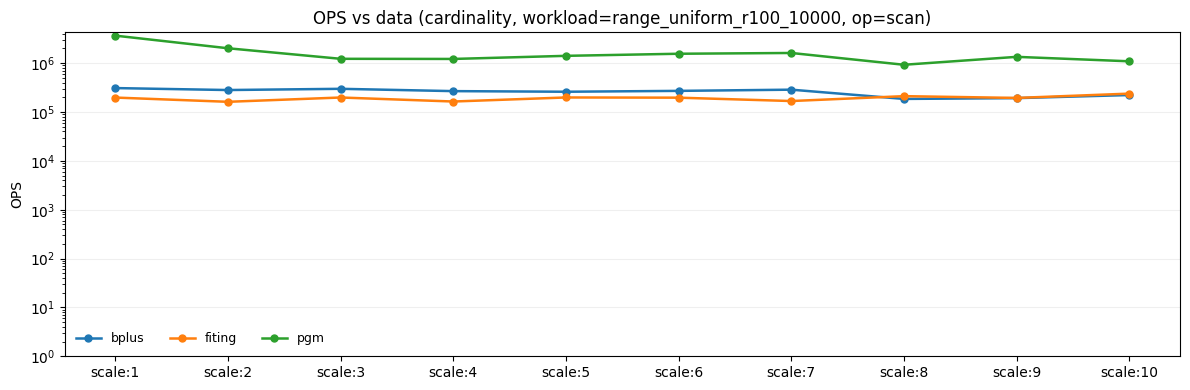

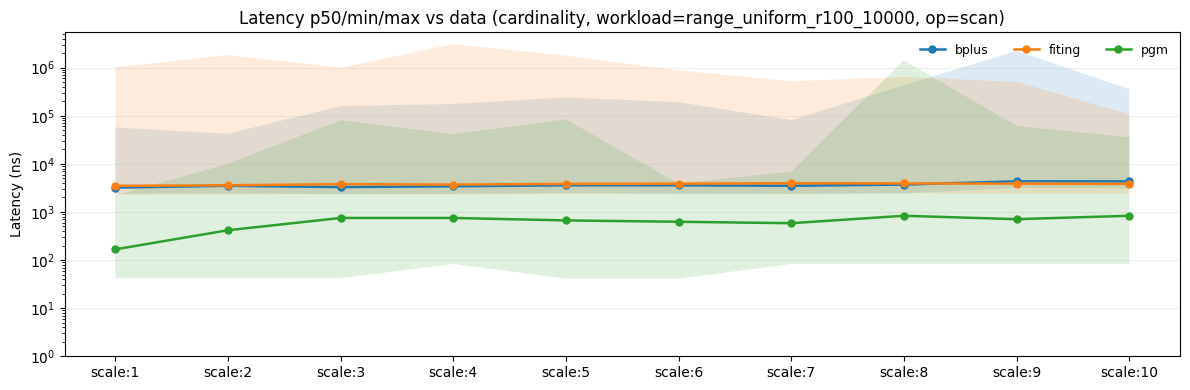

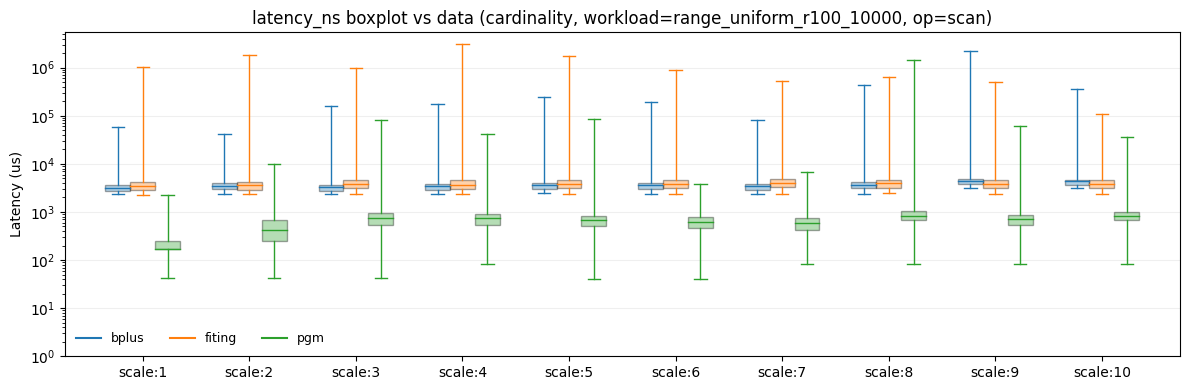

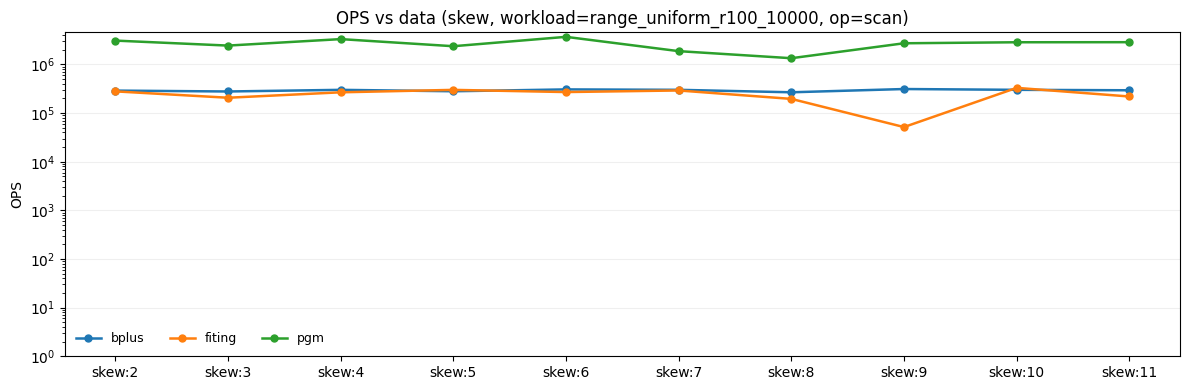

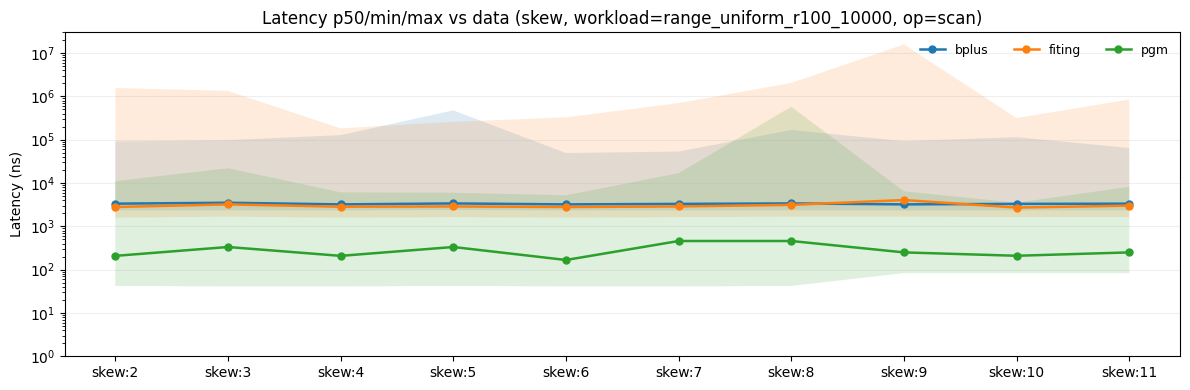

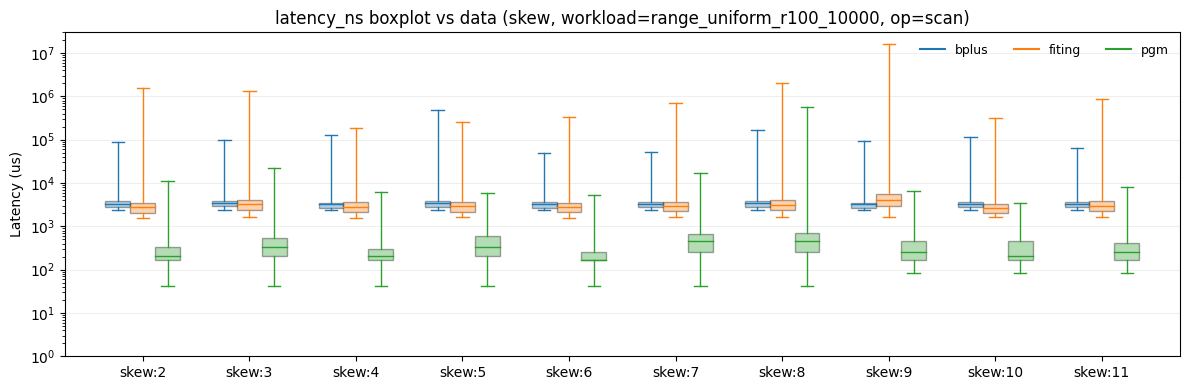

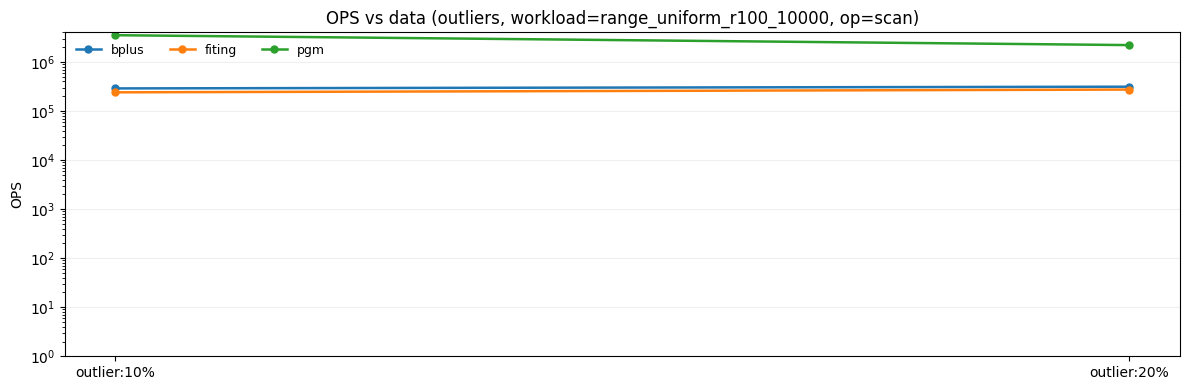

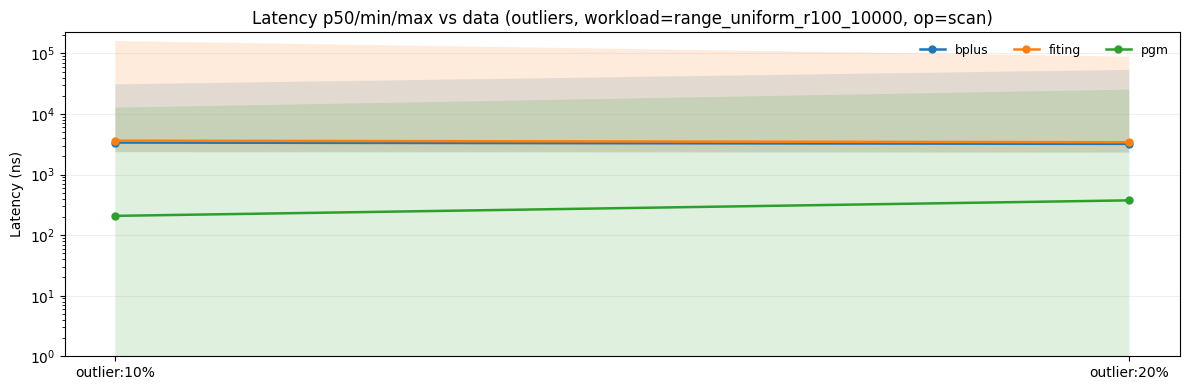

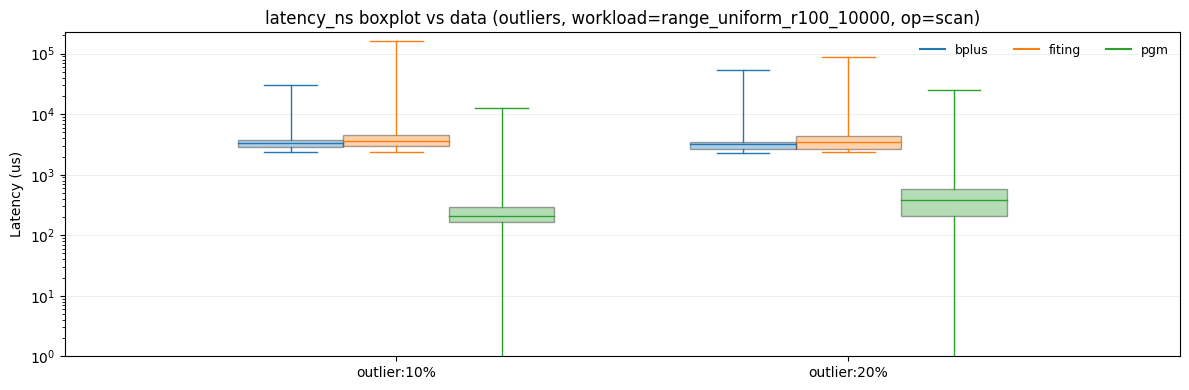

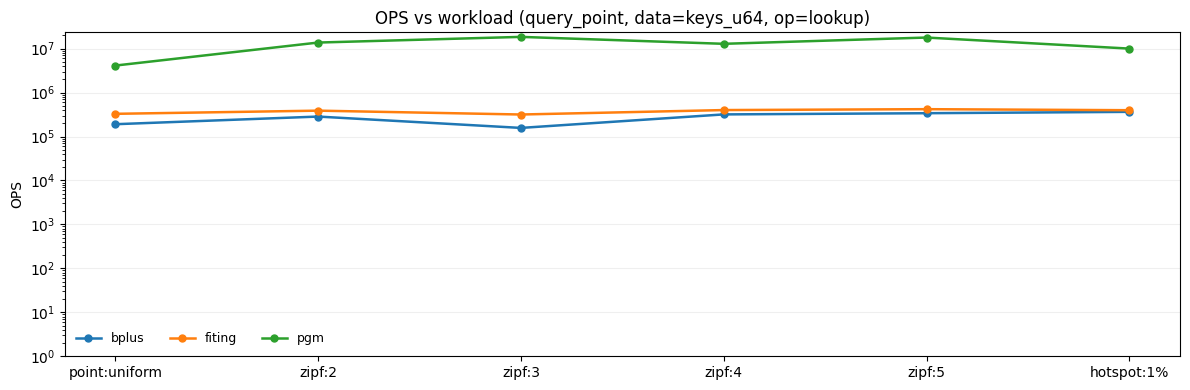

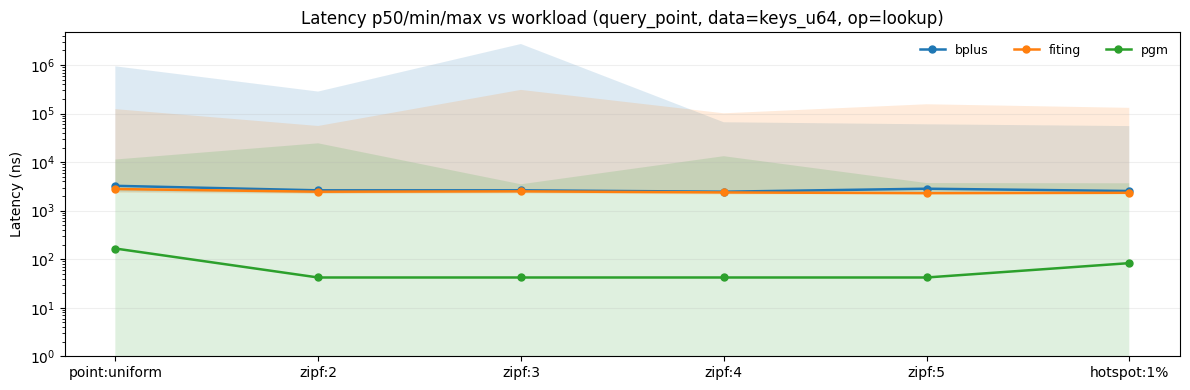

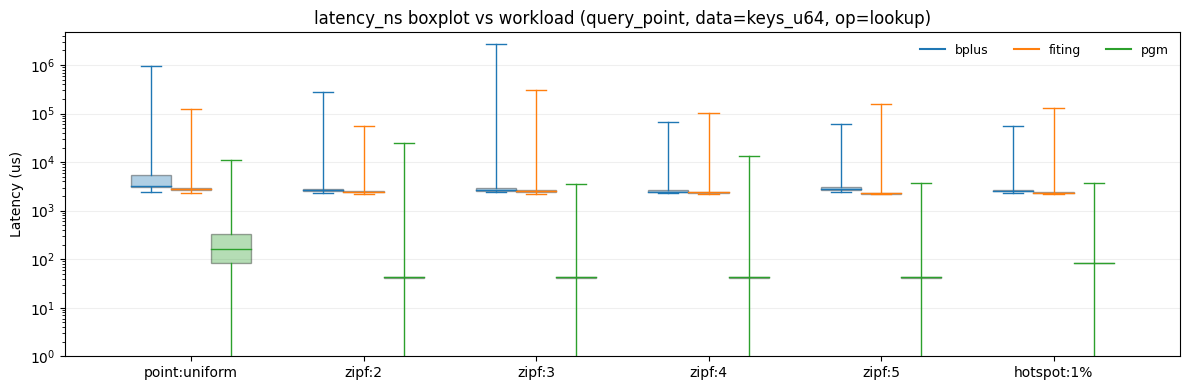

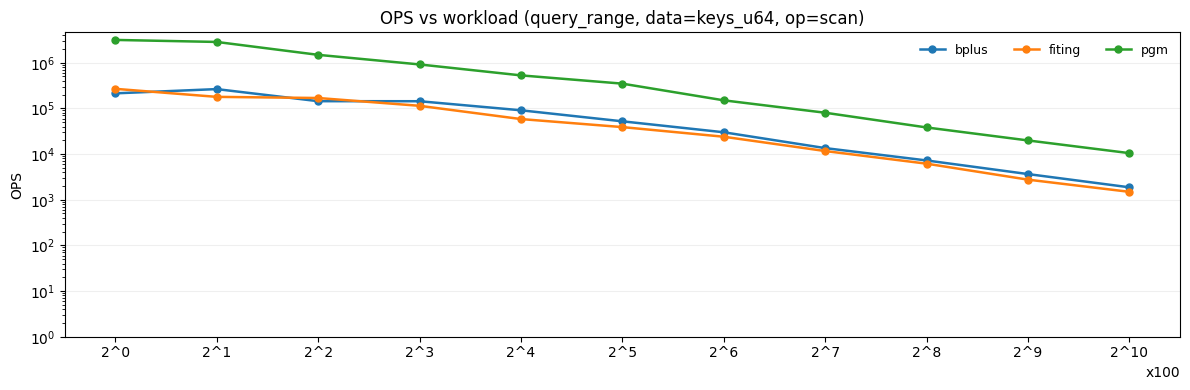

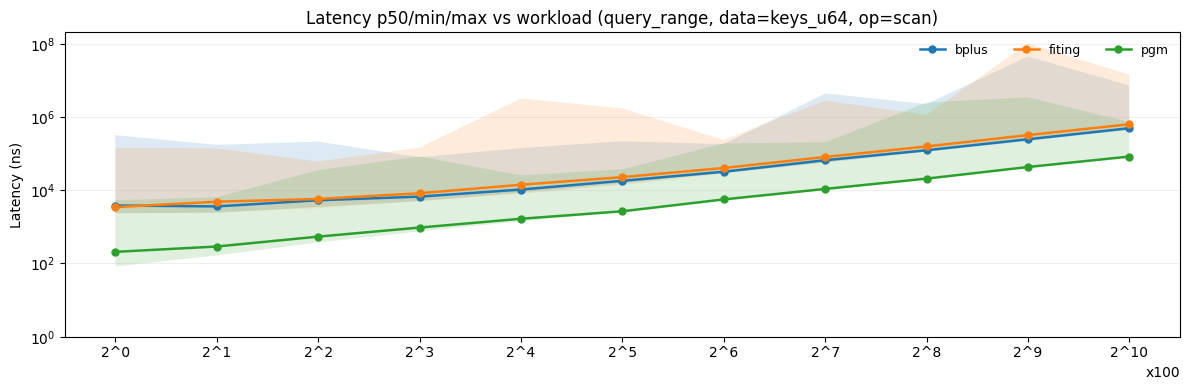

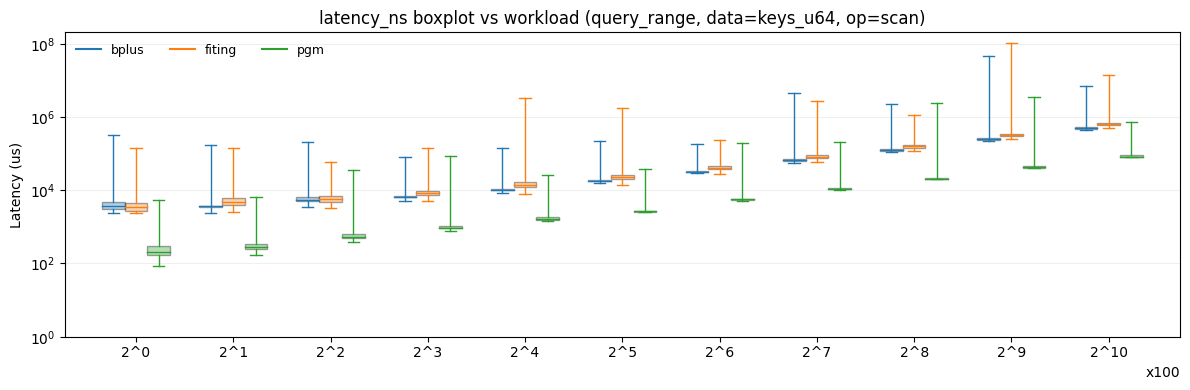

In [8]:
if RUN_BATCH:
    plot_batch()
else:
    if MODE == "by_data":
        plot_ops_by_data(TARGET_WORKLOAD, OP_TYPE)
    elif MODE == "by_workload":
        plot_ops_by_workload(TARGET_DATA, OP_TYPE)
    else:
        raise ValueError("MODE must be 'by_data' or 'by_workload'")


In [9]:
# Optional: run ad-hoc plot calls here
